In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils

In [2]:
img = cv2.imread('car.jpg')

In [3]:
gray = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)

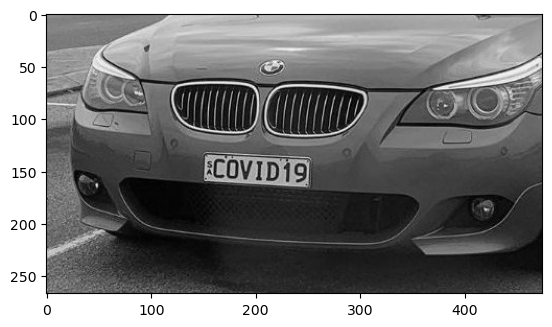

In [4]:
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

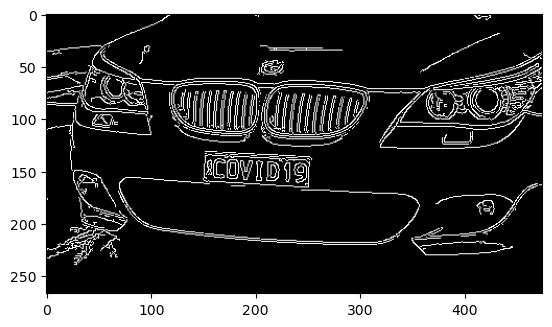

In [5]:
bfilter = cv2.bilateralFilter(gray , 11 , 17, 17) #noise redection
edged = cv2.Canny(bfilter, 30 , 200) #edge detection
plt.imshow(edged , cmap='gray')

In [6]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE , cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours , key=cv2.contourArea, reverse=True)[:10]

In [7]:
location = None

for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)

    if len(approx) == 4:
        location = approx
        break

In [8]:
location

array([[[152, 136]],

       [[248, 139]],

       [[251, 164]],

       [[153, 160]]], dtype=int32)

In [9]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask , [location], 0,255,-1)
new_image = cv2.bitwise_and(img, img , mask=mask)

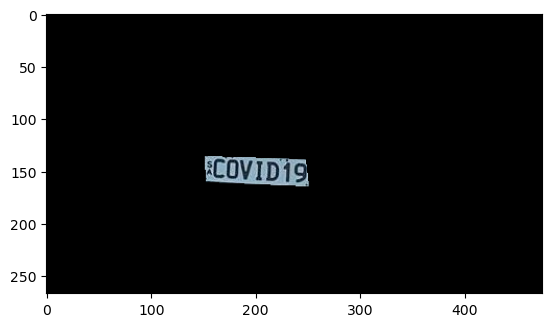

In [10]:
plt.imshow(cv2.cvtColor(new_image , cv2.COLOR_BGR2RGB))